# Phần 5 - Mô hình phân loại dựa trên LSTM/GRU

**Mục tiêu**: Xây dựng mô hình phân loại ảnh CIFAR-10 sử dụng LSTM và GRU bằng cách biểu diễn ảnh thành chuỗi (sequence).

**Dataset**: CIFAR-10 (32×32 RGB images, 10 classes: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck)

**Cách biểu diễn sequence**: Row-wise — mỗi hàng của ảnh (flatten 3 channels) là một timestep (seq_len=32, features=96)

**So sánh**: LSTM vs GRU với cùng cách biểu diễn row-wise

---
## 1. Import thư viện và thiết lập môi trường

In [1]:
# Import các thư viện cần thiết
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split

import torchvision
from torchvision import datasets, transforms

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import time
import os

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Thiết lập style cho plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ Import thành công!")
print(f"PyTorch version: {torch.__version__}")

✓ Import thành công!
PyTorch version: 2.10.0+cu128


### 1.1 Thiết lập seed cho reproducibility

In [2]:
# Set seed cho reproducibility
SEED = 42

torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
np.random.seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Kiểm tra device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

Device: cuda
GPU: Tesla T4
GPU Memory: 15.64 GB


### 1.2 Định nghĩa hyperparameters

In [3]:
# Hyperparameters
BATCH_SIZE = 128
NUM_EPOCHS = 15
LEARNING_RATE = 0.001
HIDDEN_SIZE = 128
NUM_LAYERS = 2
NUM_CLASSES = 10
DROPOUT = 0.2

# Tên các lớp trong CIFAR-10
CLASS_NAMES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# Row-wise sequence: mỗi hàng flatten 3 channels → 32*3 = 96 features
INPUT_SIZE = 96   # 32 pixels × 3 channels
SEQ_LENGTH = 32   # 32 hàng

print("Hyperparameters:")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Epochs: {NUM_EPOCHS}")
print(f"  Learning rate: {LEARNING_RATE}")
print(f"  Hidden size: {HIDDEN_SIZE}")
print(f"  Num layers: {NUM_LAYERS}")
print(f"\nCIFAR-10 classes: {CLASS_NAMES}")
print(f"\nRow-wise sequence: seq_len={SEQ_LENGTH}, input_size={INPUT_SIZE}")

Hyperparameters:
  Batch size: 128
  Epochs: 15
  Learning rate: 0.001
  Hidden size: 128
  Num layers: 2

CIFAR-10 classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

Row-wise sequence: seq_len=32, input_size=96


---
## 2. Tải và chuẩn bị dữ liệu CIFAR-10

In [4]:
# Định nghĩa transforms cho CIFAR-10
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))  # CIFAR-10 mean và std
])

# Tải CIFAR-10 dataset
train_dataset = datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

# Chia train thành train/val (45000/5000)
train_size = 45000
val_size = len(train_dataset) - train_size
train_dataset, val_dataset = random_split(
    train_dataset, 
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

# Tạo DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True if torch.cuda.is_available() else False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True if torch.cuda.is_available() else False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True if torch.cuda.is_available() else False
)

print(f"✓ Dataset loaded successfully!")
print(f"  Train: {len(train_dataset)} samples")
print(f"  Val: {len(val_dataset)} samples")
print(f"  Test: {len(test_dataset)} samples")
print(f"  Batches per epoch: {len(train_loader)}")

100%|██████████| 170M/170M [00:03<00:00, 51.9MB/s] 


✓ Dataset loaded successfully!
  Train: 45000 samples
  Val: 5000 samples
  Test: 10000 samples
  Batches per epoch: 352


### 2.1 Visualize dữ liệu mẫu

Batch shape: torch.Size([128, 3, 32, 32])
Labels shape: torch.Size([128])
Data type: torch.float32
Value range: [-1.989, 2.126]


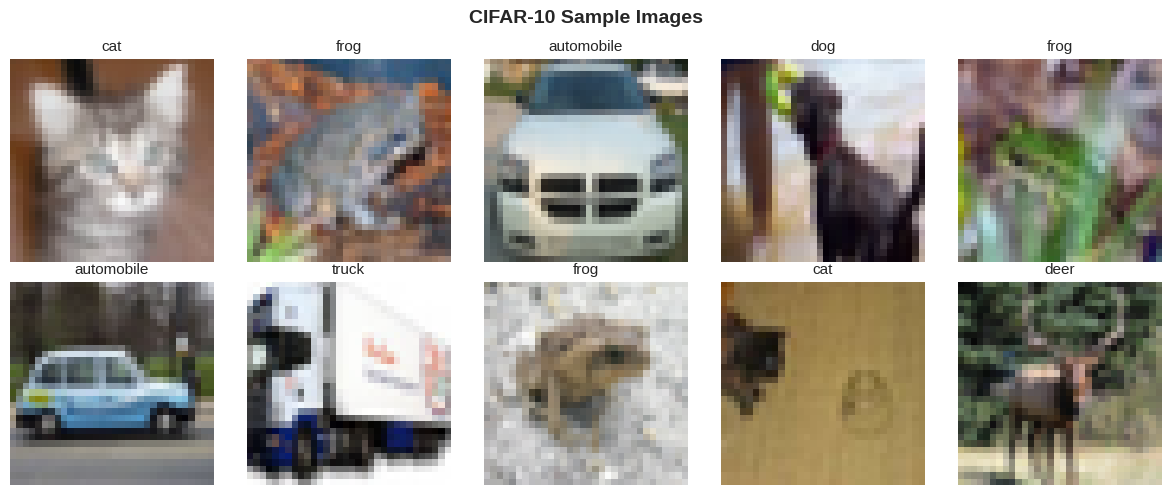

In [5]:
# Lấy một batch để visualize
sample_images, sample_labels = next(iter(train_loader))

print(f"Batch shape: {sample_images.shape}")  # (batch_size, 3, 32, 32)
print(f"Labels shape: {sample_labels.shape}")  # (batch_size,)
print(f"Data type: {sample_images.dtype}")
print(f"Value range: [{sample_images.min():.3f}, {sample_images.max():.3f}]")

# Hàm denormalize để hiển thị ảnh
def denormalize(img):
    mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
    std = torch.tensor([0.2470, 0.2435, 0.2616]).view(3, 1, 1)
    img = img * std + mean
    return img.clamp(0, 1)

# Visualize 10 ảnh đầu tiên
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle('CIFAR-10 Sample Images', fontsize=14, fontweight='bold')

for idx, ax in enumerate(axes.flat):
    img = denormalize(sample_images[idx])
    img = img.permute(1, 2, 0).numpy()  # (C, H, W) → (H, W, C) cho matplotlib
    label = sample_labels[idx].item()
    
    ax.imshow(img)
    ax.set_title(f'{CLASS_NAMES[label]}', fontsize=11)
    ax.axis('off')

plt.tight_layout()
plt.show()

---
## 3. Định nghĩa hàm biến đổi Row-wise Sequence

Biểu diễn ảnh RGB thành chuỗi bằng cách flatten 3 channels vào mỗi hàng.

In [6]:
def row_wise_sequence(images):
    """
    Biểu diễn ảnh theo hàng: mỗi hàng (flatten 3 channels) là một timestep.
    
    Args:
        images: Tensor shape (batch, 3, 32, 32)
    
    Returns:
        Tensor shape (batch, 32, 96)
        - 32 timesteps (mỗi hàng)
        - 96 features (32 pixels × 3 channels)
    """
    batch_size = images.size(0)
    # (batch, 3, 32, 32) → (batch, 32, 32, 3) → (batch, 32, 96)
    images = images.permute(0, 2, 3, 1)  # (batch, H, W, C)
    return images.reshape(batch_size, 32, -1)  # (batch, 32, 96)


# Test
test_seq = row_wise_sequence(sample_images[0:1])
print(f"Input shape: {sample_images[0:1].shape}")  # (1, 3, 32, 32)
print(f"Row-wise sequence shape: {test_seq.shape}")  # (1, 32, 96)
print("✓ Row-wise sequence transformation defined!")

Input shape: torch.Size([1, 3, 32, 32])
Row-wise sequence shape: torch.Size([1, 32, 96])
✓ Row-wise sequence transformation defined!


---
## 4. Định nghĩa kiến trúc mô hình

Chúng ta sẽ xây dựng 2 classes: `LSTMClassifier` và `GRUClassifier`.

In [7]:
class LSTMClassifier(nn.Module):
    """
    LSTM classifier cho phân loại ảnh CIFAR-10 với row-wise sequence.
    """
    
    def __init__(self, input_size, hidden_size, num_layers, num_classes, dropout=0.2):
        super(LSTMClassifier, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.fc = nn.Linear(hidden_size, num_classes)
    
    def forward(self, x):
        # (batch, 3, 32, 32) → row-wise sequence → (batch, 32, 96)
        x = row_wise_sequence(x)
        out, (h_n, c_n) = self.lstm(x)
        out = out[:, -1, :]  # Lấy output timestep cuối
        out = self.fc(out)
        return out


class GRUClassifier(nn.Module):
    """
    GRU classifier cho phân loại ảnh CIFAR-10 với row-wise sequence.
    """
    
    def __init__(self, input_size, hidden_size, num_layers, num_classes, dropout=0.2):
        super(GRUClassifier, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.fc = nn.Linear(hidden_size, num_classes)
    
    def forward(self, x):
        # (batch, 3, 32, 32) → row-wise sequence → (batch, 32, 96)
        x = row_wise_sequence(x)
        out, h_n = self.gru(x)
        out = out[:, -1, :]  # Lấy output timestep cuối
        out = self.fc(out)
        return out


print("✓ Model classes defined!")

✓ Model classes defined!


### 4.1 Test model và hiển thị architecture

In [8]:
# Test cả 2 models
test_input = torch.randn(2, 3, 32, 32).to(device)

for name, ModelClass in [('LSTM', LSTMClassifier), ('GRU', GRUClassifier)]:
    model = ModelClass(
        input_size=INPUT_SIZE, hidden_size=HIDDEN_SIZE,
        num_layers=NUM_LAYERS, num_classes=NUM_CLASSES, dropout=DROPOUT
    ).to(device)
    output = model(test_input)
    params = sum(p.numel() for p in model.parameters())
    print(f"{name}: input {test_input.shape} → output {output.shape}, params: {params:,}")
    del model, output

torch.cuda.empty_cache() if torch.cuda.is_available() else None
print("\n✓ Forward pass successful!")

LSTM: input torch.Size([2, 3, 32, 32]) → output torch.Size([2, 10]), params: 249,098
GRU: input torch.Size([2, 3, 32, 32]) → output torch.Size([2, 10]), params: 187,146

✓ Forward pass successful!


---
## 5. Training và Evaluation Functions

In [9]:
def train_one_epoch(model, train_loader, criterion, optimizer, device, epoch):
    """
    Train model cho 1 epoch.
    
    Returns:
        avg_loss, accuracy
    """
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{NUM_EPOCHS} [Train]')
    
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)
        
        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Backward pass và optimization
        optimizer.zero_grad()
        loss.backward()
        
        # Gradient clipping để tránh exploding gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        # Statistics
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
        # Update progress bar
        pbar.set_postfix({
            'loss': f'{running_loss/(pbar.n+1):.4f}',
            'acc': f'{100.*correct/total:.2f}%'
        })
    
    avg_loss = running_loss / len(train_loader)
    accuracy = 100. * correct / total
    
    return avg_loss, accuracy


def evaluate(model, data_loader, criterion, device, mode='Val'):
    """
    Evaluate model trên validation hoặc test set.
    
    Returns:
        avg_loss, accuracy, predictions, labels
    """
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        pbar = tqdm(data_loader, desc=f'[{mode}]')
        
        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)
            
            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            # Statistics
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
            # Store predictions
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
            # Update progress bar
            pbar.set_postfix({
                'loss': f'{running_loss/(pbar.n+1):.4f}',
                'acc': f'{100.*correct/total:.2f}%'
            })
    
    avg_loss = running_loss / len(data_loader)
    accuracy = 100. * correct / total
    
    return avg_loss, accuracy, all_preds, all_labels


def train_model(model, model_name, train_loader, val_loader, 
                criterion, optimizer, device, num_epochs):
    """
    Training loop đầy đủ cho một model.
    
    Returns:
        history dict với train/val loss và accuracy
    """
    print(f"\n{'='*60}")
    print(f"Training: {model_name}")
    print(f"{'='*60}")
    
    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': []
    }
    
    best_val_acc = 0.0
    start_time = time.time()
    
    for epoch in range(num_epochs):
        # Training
        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, device, epoch
        )
        
        # Validation
        val_loss, val_acc, _, _ = evaluate(
            model, val_loader, criterion, device, mode='Val'
        )
        
        # Save history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        # Print epoch summary
        print(f"\nEpoch {epoch+1}/{num_epochs}:")
        print(f"  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
        print(f"  Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")
        
        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            print(f"  ✓ New best validation accuracy: {best_val_acc:.2f}%")
    
    training_time = time.time() - start_time
    print(f"\nTraining completed in {training_time:.2f}s")
    print(f"Best validation accuracy: {best_val_acc:.2f}%")
    
    return history, training_time


print("✓ Training functions defined!")

✓ Training functions defined!


---
## 6. Huấn luyện mô hình LSTM (Row-wise)

In [10]:
# Khởi tạo LSTM model
lstm_model = LSTMClassifier(
    input_size=INPUT_SIZE,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    num_classes=NUM_CLASSES,
    dropout=DROPOUT
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(lstm_model.parameters(), lr=LEARNING_RATE)

history_lstm, time_lstm = train_model(
    lstm_model, 'LSTM Row-wise',
    train_loader, val_loader,
    criterion, optimizer, device, NUM_EPOCHS
)


Training: LSTM Row-wise


[Val]: 100%|██████████| 40/40 [00:00<00:00, 51.41it/s, loss=1.5874, acc=41.06%]



Epoch 1/15:
  Train Loss: 1.7512, Train Acc: 35.21%
  Val Loss: 1.5874, Val Acc: 41.06%
  ✓ New best validation accuracy: 41.06%


[Val]: 100%|██████████| 40/40 [00:00<00:00, 50.89it/s, loss=1.6819, acc=48.14%]



Epoch 2/15:
  Train Loss: 1.4806, Train Acc: 46.23%
  Val Loss: 1.4296, Val Acc: 48.14%
  ✓ New best validation accuracy: 48.14%


...


Epoch 13/15:
  Train Loss: 0.7163, Train Acc: 74.67%
  Val Loss: 1.2685, Val Acc: 58.72%


[Val]: 100%|██████████| 40/40 [00:00<00:00, 50.53it/s, loss=1.4813, acc=59.10%]



Epoch 14/15:
  Train Loss: 0.6697, Train Acc: 76.48%
  Val Loss: 1.2962, Val Acc: 59.10%
  ✓ New best validation accuracy: 59.10%


[Val]: 100%|██████████| 40/40 [00:00<00:00, 51.90it/s, loss=1.3264, acc=58.80%]


Epoch 15/15:
  Train Loss: 0.6303, Train Acc: 77.88%
  Val Loss: 1.3264, Val Acc: 58.80%

Training completed in 110.46s
Best validation accuracy: 59.10%


---
## 7. Huấn luyện mô hình GRU (Row-wise)

In [11]:
# Khởi tạo GRU model
gru_model = GRUClassifier(
    input_size=INPUT_SIZE,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    num_classes=NUM_CLASSES,
    dropout=DROPOUT
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(gru_model.parameters(), lr=LEARNING_RATE)

history_gru, time_gru = train_model(
    gru_model, 'GRU Row-wise',
    train_loader, val_loader,
    criterion, optimizer, device, NUM_EPOCHS
)


Training: GRU Row-wise


[Val]: 100%|██████████| 40/40 [00:00<00:00, 53.11it/s, loss=1.7386, acc=44.12%]



Epoch 1/15:
  Train Loss: 1.7138, Train Acc: 36.72%
  Val Loss: 1.5213, Val Acc: 44.12%
  ✓ New best validation accuracy: 44.12%


[Val]: 100%|██████████| 40/40 [00:00<00:00, 51.91it/s, loss=1.3894, acc=49.90%]



Epoch 2/15:
  Train Loss: 1.4189, Train Acc: 48.43%
  Val Loss: 1.3894, Val Acc: 49.90%
  ✓ New best validation accuracy: 49.90%


...


Epoch 13/15:
  Train Loss: 0.6695, Train Acc: 76.20%
  Val Loss: 1.2035, Val Acc: 61.40%


[Val]: 100%|██████████| 40/40 [00:00<00:00, 47.23it/s, loss=1.2311, acc=60.90%]



Epoch 14/15:
  Train Loss: 0.6284, Train Acc: 77.72%
  Val Loss: 1.2311, Val Acc: 60.90%


[Val]: 100%|██████████| 40/40 [00:00<00:00, 53.59it/s, loss=1.3181, acc=61.12%]


Epoch 15/15:
  Train Loss: 0.5934, Train Acc: 79.15%
  Val Loss: 1.2522, Val Acc: 61.12%

Training completed in 108.23s
Best validation accuracy: 61.50%


---
## 8. Đánh giá trên Test Set

In [12]:
all_models = {
    'LSTM Row-wise': lstm_model,
    'GRU Row-wise': gru_model
}

all_histories = {
    'LSTM Row-wise': history_lstm,
    'GRU Row-wise': history_gru
}

all_times = {
    'LSTM Row-wise': time_lstm,
    'GRU Row-wise': time_gru
}

# Evaluate trên test set
test_results = {}
criterion = nn.CrossEntropyLoss()

print("\n" + "="*60)
print("EVALUATING ON TEST SET")
print("="*60)

for model_name, model in all_models.items():
    print(f"\nEvaluating {model_name}...")
    test_loss, test_acc, test_preds, test_labels = evaluate(
        model, test_loader, criterion, device, mode='Test'
    )
    
    num_params = sum(p.numel() for p in model.parameters())
    
    test_results[model_name] = {
        'test_loss': test_loss,
        'test_acc': test_acc,
        'predictions': test_preds,
        'labels': test_labels,
        'num_params': num_params,
        'training_time': all_times[model_name]
    }
    
    print(f"  Test Loss: {test_loss:.4f}")
    print(f"  Test Accuracy: {test_acc:.2f}%")
    print(f"  Parameters: {num_params:,}")
    print(f"  Training Time: {all_times[model_name]:.2f}s")

print("\n✓ All models evaluated!")


EVALUATING ON TEST SET

Evaluating LSTM Row-wise...


[Test]: 100%|██████████| 79/79 [00:01<00:00, 54.98it/s, loss=1.3998, acc=59.24%]


  Test Loss: 1.3112
  Test Accuracy: 59.24%
  Parameters: 249,098
  Training Time: 110.46s

Evaluating GRU Row-wise...


[Test]: 100%|██████████| 79/79 [00:01<00:00, 56.10it/s, loss=1.3588, acc=61.09%]

  Test Loss: 1.2556
  Test Accuracy: 61.09%
  Parameters: 187,146
  Training Time: 108.23s

✓ All models evaluated!


---
## 9. So sánh LSTM vs GRU

### 9.1 Bảng so sánh

In [13]:
# Bảng so sánh LSTM vs GRU
comparison_data = []
for model_name, results in test_results.items():
    history = all_histories[model_name]
    comparison_data.append({
        'Model': model_name,
        'Test Accuracy (%)': f"{results['test_acc']:.2f}",
        'Test Loss': f"{results['test_loss']:.4f}",
        'Best Val Acc (%)': f"{max(history['val_acc']):.2f}",
        'Parameters': f"{results['num_params']:,}",
        'Training Time (s)': f"{results['training_time']:.2f}"
    })

comparison_df = pd.DataFrame(comparison_data)
print("\n" + "="*70)
print("SO SÁNH LSTM vs GRU (Row-wise Sequence)")
print("="*70)
print(comparison_df.to_string(index=False))
print("="*70)


SO SÁNH LSTM vs GRU (Row-wise Sequence)
        Model Test Accuracy (%) Test Loss Best Val Acc (%) Parameters Training Time (s)
LSTM Row-wise             59.24    1.3112            59.10    249,098            110.46
 GRU Row-wise             61.09    1.2556            61.50    187,146            108.23


### 9.2 So sánh Test Accuracy

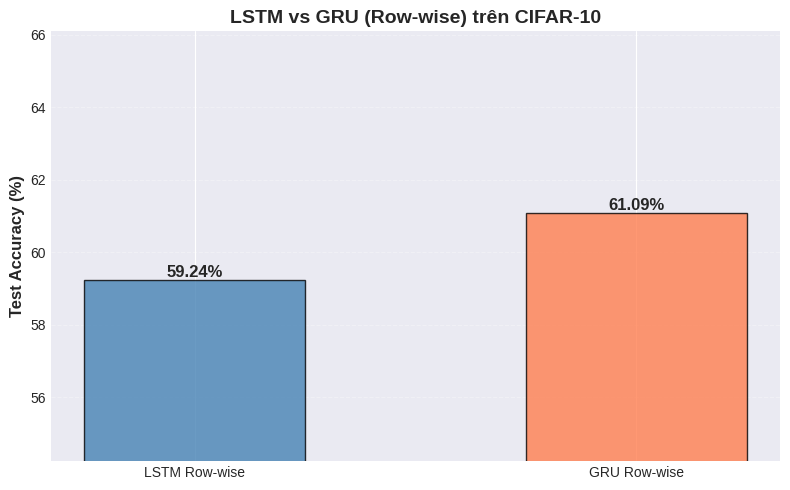

In [14]:
# Bar chart LSTM vs GRU
fig, ax = plt.subplots(figsize=(8, 5))

models = list(test_results.keys())
accuracies = [test_results[m]['test_acc'] for m in models]
colors = ['steelblue', 'coral']

bars = ax.bar(models, accuracies, color=colors, alpha=0.8, edgecolor='black', width=0.5)

for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
            f'{acc:.2f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylabel('Test Accuracy (%)', fontsize=12, fontweight='bold')
ax.set_title('LSTM vs GRU (Row-wise) trên CIFAR-10', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim([min(accuracies) - 5, max(accuracies) + 5])

plt.tight_layout()
plt.show()

### 9.3 Training Curves

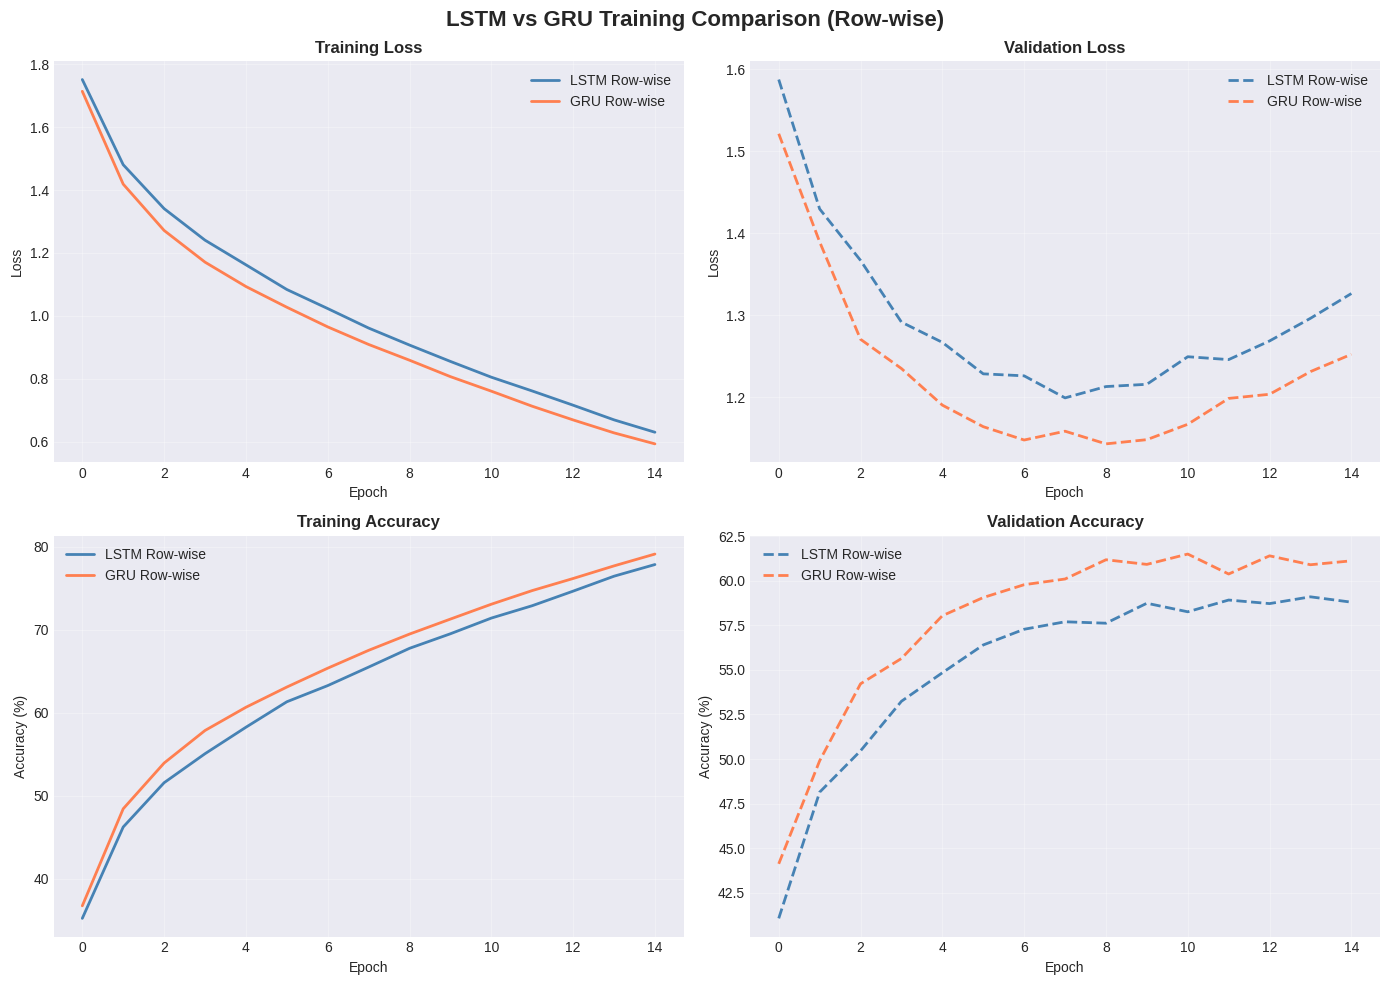

In [15]:
# Training curves comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('LSTM vs GRU Training Comparison (Row-wise)', fontsize=16, fontweight='bold')

colors = {'LSTM Row-wise': 'steelblue', 'GRU Row-wise': 'coral'}

for model_name, history in all_histories.items():
    c = colors[model_name]
    axes[0,0].plot(history['train_loss'], label=model_name, linewidth=2, color=c)
    axes[0,1].plot(history['val_loss'], label=model_name, linewidth=2, color=c, linestyle='--')
    axes[1,0].plot(history['train_acc'], label=model_name, linewidth=2, color=c)
    axes[1,1].plot(history['val_acc'], label=model_name, linewidth=2, color=c, linestyle='--')

for ax, title, ylabel in [
    (axes[0,0], 'Training Loss', 'Loss'),
    (axes[0,1], 'Validation Loss', 'Loss'),
    (axes[1,0], 'Training Accuracy', 'Accuracy (%)'),
    (axes[1,1], 'Validation Accuracy', 'Accuracy (%)')]:
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 9.4 Confusion Matrix

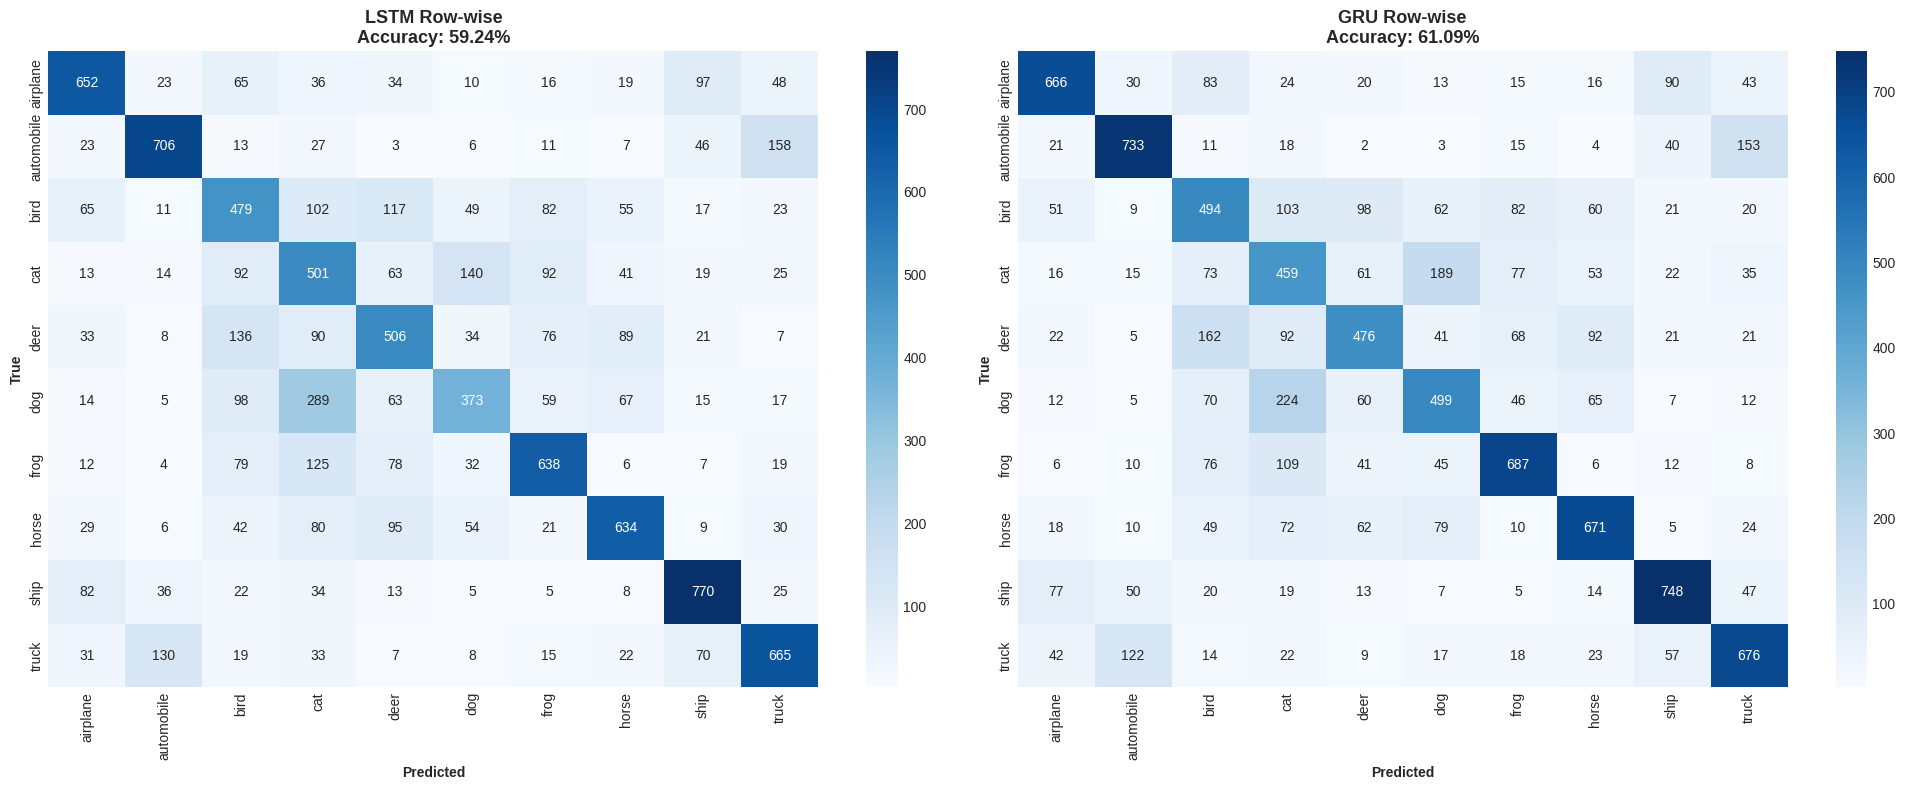


Classification Report - GRU Row-wise:
              precision    recall  f1-score   support

    airplane       0.72      0.67      0.69      1000
  automobile       0.74      0.73      0.74      1000
        bird       0.47      0.49      0.48      1000
         cat       0.40      0.46      0.43      1000
        deer       0.57      0.48      0.52      1000
         dog       0.52      0.50      0.51      1000
        frog       0.67      0.69      0.68      1000
       horse       0.67      0.67      0.67      1000
        ship       0.73      0.75      0.74      1000
       truck       0.65      0.68      0.66      1000

    accuracy                           0.61     10000
   macro avg       0.61      0.61      0.61     10000
weighted avg       0.61      0.61      0.61     10000



In [16]:
# Confusion matrix cho cả 2 models
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

for idx, (model_name, results) in enumerate(test_results.items()):
    cm = confusion_matrix(results['labels'], results['predictions'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                ax=axes[idx])
    axes[idx].set_xlabel('Predicted', fontweight='bold')
    axes[idx].set_ylabel('True', fontweight='bold')
    axes[idx].set_title(f'{model_name}\nAccuracy: {results["test_acc"]:.2f}%',
                       fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

# Classification report cho best model
best_name = max(test_results, key=lambda x: test_results[x]['test_acc'])
best = test_results[best_name]
print(f"\nClassification Report - {best_name}:")
print("="*60)
print(classification_report(best['labels'], best['predictions'],
                          target_names=CLASS_NAMES))